<a href="https://colab.research.google.com/github/Dexter0013/Deepraj-Singha-6th-Sem-CSE-Data-Mining-Assignments/blob/main/4.%20Random%20Forest%20Classification%20on%20uciml-breast-cancer-wisconsin-data/Random_Forest_Classification_on_uciml_breast_cancer_wisconsin_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Step 1: Load all the lib and dataset uciml/breast-cancer-wisconsin-data**

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.
Path to dataset files: /kaggle/input/breast-cancer-wisconsin-data


In [7]:
import pandas as pd
import os

# Load dataset
df = pd.read_csv("/kaggle/input/breast-cancer-wisconsin-data/data.csv")

# Drop unnecessary columns
df = df.drop(columns=[col for col in df.columns if 'Unnamed' in col])

# Replace B with benign and M with malignant
df['diagnosis'] = df['diagnosis'].replace({'B': 'benign', 'M': 'malignant'})

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,malignant,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,malignant,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,malignant,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,malignant,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,malignant,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


**Step 2: Data Preprocessing and Model Training**

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Encode target variable
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])

# Define features and target
X = df.drop(['id', 'diagnosis'], axis=1)
y = df['diagnosis']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy Score: 0.9649

Classification Report:
              precision    recall  f1-score   support

      benign       0.96      0.99      0.97        71
   malignant       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



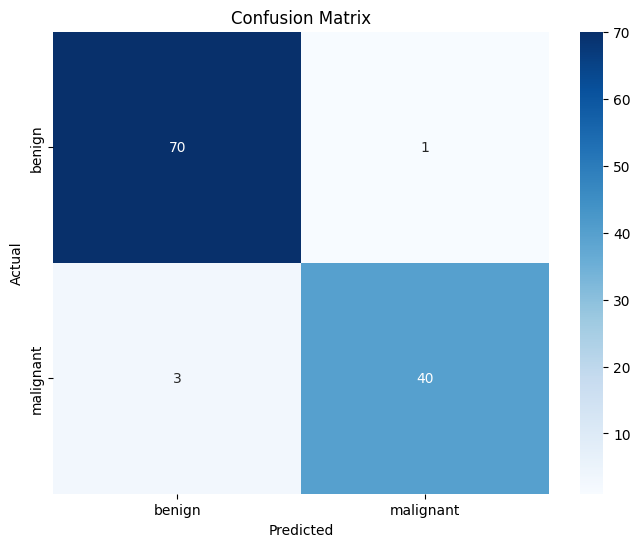

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

**Saving the model**

In [10]:
import joblib

# Save the model, scaler, and label encoder
joblib.dump(model, 'breast_cancer_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

print("Model and preprocessing objects saved successfully!")

Model and preprocessing objects saved successfully!


**Loading the saved Model**

In [11]:
# Load the saved objects
loaded_model = joblib.load('breast_cancer_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

# Verification: Predict using the loaded model
loaded_preds = loaded_model.predict(X_test)
print(f"Loaded Model Accuracy: {accuracy_score(y_test, loaded_preds):.4f}")

Loaded Model Accuracy: 0.9649
